# Github Connectivity project

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict, Counter

G = nx.read_gexf('exploration_state.gexf')

print(f"Network loaded successfully!")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Network loaded successfully!
Nodes: 48951
Edges: 2279238


# Nogle små stats

In [3]:
density = nx.density(G)
print(f"Network density: {density:.4f}")

avg_clustering = nx.average_clustering(G.to_undirected())
print(f"Average clustering coefficient: {avg_clustering:.4f}")

Network density: 0.0019
Average clustering coefficient: 0.9201


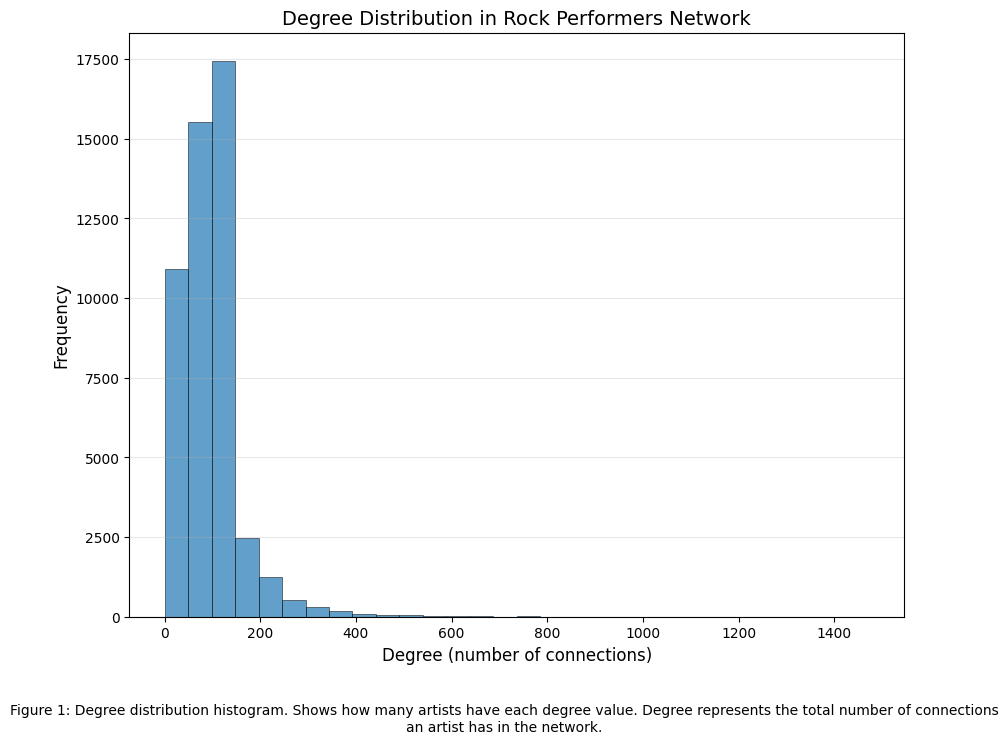


Degree statistics:
Average degree: 93.12
Median degree: 98.00
Max degree: 1473
Min degree: 0


In [5]:
# Get degrees for all nodes (undirected graph)
degrees = [G.degree(node) for node in G.nodes()]

# Create histogram or degree distribution plot
plt.figure(figsize=(10, 8))
plt.hist(degrees, bins=30, alpha=0.7, edgecolor='black', linewidth=0.5)
plt.xlabel('Degree (number of connections)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Degree Distribution in Rock Performers Network', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

plt.figtext(0.5, 0.01, "Figure 1: Degree distribution histogram. Shows how many artists have each degree value. " \
"Degree represents the total number of connections an artist has in the network.", 
ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.15)
plt.show()

# Print some statistics
print(f"\nDegree statistics:")
print(f"Average degree: {np.mean(degrees):.2f}")
print(f"Median degree: {np.median(degrees):.2f}")
print(f"Max degree: {max(degrees)}")
print(f"Min degree: {min(degrees)}")

In [8]:
G_undirected = G
assortativity = nx.degree_assortativity_coefficient(G_undirected)
print(f"Degree Assortativity Coefficient: {assortativity:.4f}")

Degree Assortativity Coefficient: 0.1330


# Til backbone

In [3]:
def disparity_filter(G, alpha=0.135):
    """
    Apply disparity filter to extract network backbone.
    
    For each node, the disparity filter tests whether each edge weight
    is significantly larger than expected under a null model.
    """
    B = nx.Graph()
    B.add_nodes_from(G.nodes(data=True))
    
    for node in G.nodes():
        edges = list(G.edges(node, data=True))
        
        if len(edges) == 0:
            continue
            
        k = len(edges)  # degree
        s = sum(d.get('weight', 1) for u, v, d in edges)  # total strength
        
        for u, v, data in edges:
            weight = data.get('weight', 1)
            
            if s > 0:
                # Disparity filter p-value
                p_value = (1 - weight / s) ** (k - 1)
                
                if p_value < alpha:
                    if not B.has_edge(u, v):
                        B.add_edge(u, v, weight=weight, p_value=p_value)
    
    return B

# Create weighted graph from your original graph G
# Use the computed edge betweenness as weights
# Count shared projects as edge weights
G_weighted = nx.Graph()
G_weighted.add_nodes_from(G.nodes(data=True))

shared_projects_count = 0
for u, v in G.edges():
    # Get the set of repos for each user
    repos_u = G.nodes[u].get('repos', set())
    repos_v = G.nodes[v].get('repos', set())
    
    # Convert string to set if needed (in case it was saved as string in GEXF)
    if isinstance(repos_u, str):
        repos_u = set(repos_u.split(", ")) if repos_u else set()
    if isinstance(repos_v, str):
        repos_v = set(repos_v.split(", ")) if repos_v else set()
    
    # Count shared repos
    shared = len(repos_u & repos_v)  # Set intersection
    
    if shared > 0:
        G_weighted.add_edge(u, v, weight=shared)
        if shared > 1:
            shared_projects_count += 1

print(f"\nWeight distribution:")
weights = [d['weight'] for u, v, d in G_weighted.edges(data=True)]
print(f"  Min: {min(weights)}, Max: {max(weights)}, Mean: {np.mean(weights):.2f}")
print(f"  Median: {np.median(weights):.1f}")
print(f"  Edges with weight > 1: {sum(1 for w in weights if w > 1)} ({100*sum(1 for w in weights if w > 1)/len(weights):.1f}%)")


Weight distribution:
  Min: 1, Max: 123, Mean: 1.58
  Median: 1.0
  Edges with weight > 1: 316472 (13.9%)


# Backbone gen

In [31]:
# Now apply the disparity filter
backbone = disparity_filter(G_weighted, alpha=0.3687)

# Remove isolated nodes
isolated = [node for node in backbone.nodes() if backbone.degree(node) == 0]
backbone.remove_nodes_from(isolated)

# Keep only the largest connected component
if not nx.is_connected(backbone):
    components = list(nx.connected_components(backbone))
    largest_cc = max(components, key=len)
    nodes_to_remove = set(backbone.nodes()) - largest_cc
    backbone.remove_nodes_from(nodes_to_remove)
    print(f"Removed {len(nodes_to_remove)} nodes in smaller components")
    print(f"Kept largest connected component with {len(largest_cc)} nodes")

# Report statistics
print(f"\nBackbone Statistics:")
print(f"  Nodes: {backbone.number_of_nodes()} ({100*backbone.number_of_nodes()/G.number_of_nodes():.1f}% of original)")
print(f"  Edges: {backbone.number_of_edges()} ({100*backbone.number_of_edges()/G_weighted.number_of_edges():.1f}% of original)")
print(f"  Density: {nx.density(backbone):.4f} (original: {nx.density(G_weighted):.4f})")
print(f"  Connected: {nx.is_connected(backbone)}")

Removed 294 nodes in smaller components
Kept largest connected component with 21595 nodes

Backbone Statistics:
  Nodes: 21595 (44.1% of original)
  Edges: 313701 (13.8% of original)
  Density: 0.0013 (original: 0.0019)
  Connected: True


# Lidt for sjov her shortest path

In [54]:
import networkx as nx

def shortest_path_between_users(G, source_user, target_user):
    """
    Find the shortest path (in hops) from source_user to target_user.

    Parameters:
        G (nx.Graph): The GitHub collaboration graph.
        source_user (str): Starting username.
        target_user (str): Target username.

    Returns:
        path (list): List of users from source_user to target_user.
    """
    if source_user not in G:
        raise ValueError(f"User '{source_user}' not found in graph")

    if target_user not in G:
        raise ValueError(f"User '{target_user}' not found in graph")

    try:
        path = nx.shortest_path(G, source=source_user, target=target_user)
        return path
    except nx.NetworkXNoPath:
        raise nx.NetworkXNoPath(
            f"No path found from '{source_user}' to '{target_user}'"
        )
    

shortest_path_between_users(backbone, 'Pakkutaq', 'torvalds')

['Pakkutaq', 'gh05tdog', 'dliappis', '0xflotus', 'tiwai', 'torvalds']

# Centrality

In [36]:
import networkx as nx

print(f"Computing degree centrality on backbone ({backbone.number_of_nodes()} nodes, {backbone.number_of_edges()} edges)...")
degree_centrality = nx.degree_centrality(backbone)
print("✓ Degree centrality complete")

# Get top users
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("\n" + "="*60)
print("Top 10 by Degree Centrality:")
for i, (user, val) in enumerate(top_degree, 1):
    print(f"  {i:2d}. {user:30s} {val:.6f}")
print("="*60)

Computing degree centrality on backbone (21889 nodes, 315691 edges)...
✓ Degree centrality complete

Top 10 by Degree Centrality:
   1. lcawl                          0.035179
   2. clintongormley                 0.031524
   3. 0xflotus                       0.030885
   4. ycombinator                    0.028372
   5. dedemorton                     0.026818
   6. debadair                       0.026042
   7. nik9000                        0.025813
   8. honzakral                      0.024580
   9. bleskes                        0.023666
  10. martijnvg                      0.023620


In [37]:
import numpy as np
from joblib import Parallel, delayed

print("Computing betweenness centrality (exact, parallelized)...")

def compute_betweenness_chunk(G, nodes):
    """Compute exact betweenness for a chunk of nodes as sources"""
    return nx.betweenness_centrality_subset(
        G, 
        sources=nodes, 
        targets=G.nodes(),
        normalized=True
    )

n_jobs = 12
node_chunks = np.array_split(list(backbone.nodes()), n_jobs)

results = Parallel(n_jobs=n_jobs)(
    delayed(compute_betweenness_chunk)(backbone, chunk.tolist()) 
    for chunk in node_chunks
)

betweenness_centrality = {}
for result in results:
    for node, value in result.items():
        betweenness_centrality[node] = betweenness_centrality.get(node, 0) + value

print("✓ Betweenness centrality complete")

# Get top users
top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("\n" + "="*60)
print("Top 10 by Betweenness Centrality:")
for i, (user, val) in enumerate(top_betweenness, 1):
    print(f"  {i:2d}. {user:30s} {val:.6f}")
print("="*60)

Computing betweenness centrality (exact, parallelized)...
✓ Betweenness centrality complete

Top 10 by Betweenness Centrality:
   1. 0xflotus                       0.068736
   2. scop                           0.033056
   3. probonopd                      0.031225
   4. dandv                          0.030848
   5. gregwebs                       0.029801
   6. DenisCarriere                  0.029328
   7. jsoref                         0.026751
   8. DavidKorczynski                0.025776
   9. algernon                       0.024783
  10. smola                          0.024430


In [38]:
print("Computing closeness centrality (exact)...")
closeness_centrality = nx.closeness_centrality(backbone)
print("✓ Closeness centrality complete")

# Get top users
top_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("\n" + "="*60)
print("Top 10 by Closeness Centrality:")
for i, (user, val) in enumerate(top_closeness, 1):
    print(f"  {i:2d}. {user:30s} {val:.6f}")
print("="*60)

Computing closeness centrality (exact)...
✓ Closeness centrality complete

Top 10 by Closeness Centrality:
   1. 0xflotus                       0.332148
   2. jsoref                         0.324394
   3. bleskes                        0.323901
   4. msabramo                       0.323758
   5. honzakral                      0.323051
   6. scop                           0.321239
   7. lcawl                          0.320751
   8. dedemorton                     0.320351
   9. clintongormley                 0.317642
  10. luzpaz                         0.317188


# Top 5 users

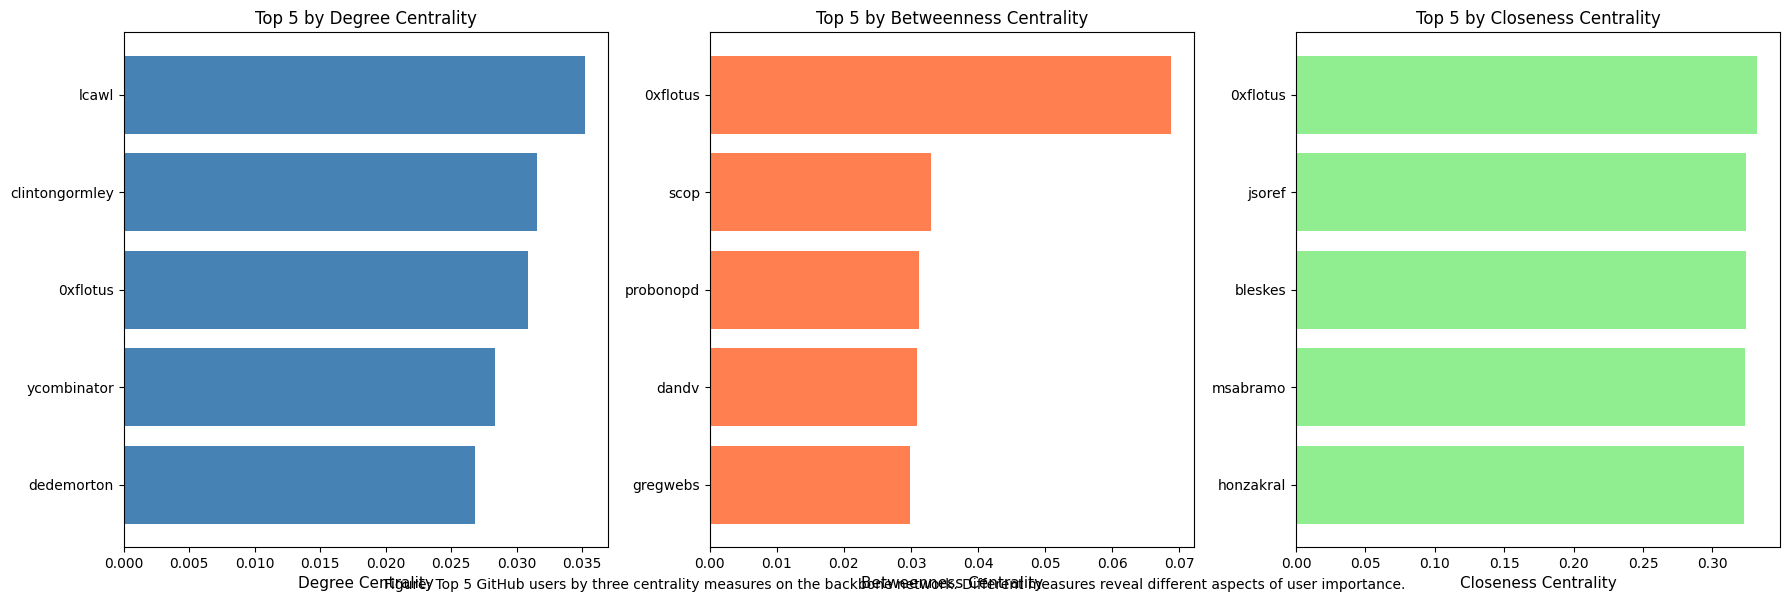

In [39]:
import matplotlib.pyplot as plt

# Visualize top 5 users by each centrality measure
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Degree Centrality
top_5_degree = top_degree[:5]
users_deg = [user for user, _ in top_5_degree]
values_deg = [val for _, val in top_5_degree]
axs[0].barh(users_deg, values_deg, color='steelblue')
axs[0].set_xlabel('Degree Centrality', fontsize=11)
axs[0].set_title('Top 5 by Degree Centrality', fontsize=12)
axs[0].invert_yaxis()

# Betweenness Centrality
top_5_bet = top_betweenness[:5]
users_bet = [user for user, _ in top_5_bet]
values_bet = [val for _, val in top_5_bet]
axs[1].barh(users_bet, values_bet, color='coral')
axs[1].set_xlabel('Betweenness Centrality', fontsize=11)
axs[1].set_title('Top 5 by Betweenness Centrality', fontsize=12)
axs[1].invert_yaxis()

# Closeness Centrality
top_5_close = top_closeness[:5]
users_close = [user for user, _ in top_5_close]
values_close = [val for _, val in top_5_close]
axs[2].barh(users_close, values_close, color='lightgreen')
axs[2].set_xlabel('Closeness Centrality', fontsize=11)
axs[2].set_title('Top 5 by Closeness Centrality', fontsize=12)
axs[2].invert_yaxis()

plt.figtext(0.5, 0.01, 
            "Figure: Top 5 GitHub users by three centrality measures on the backbone network. " \
            "Different measures reveal different aspects of user importance.",
            ha="center", fontsize=10, wrap=True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

# Degree vs betweennes centrality correlation check

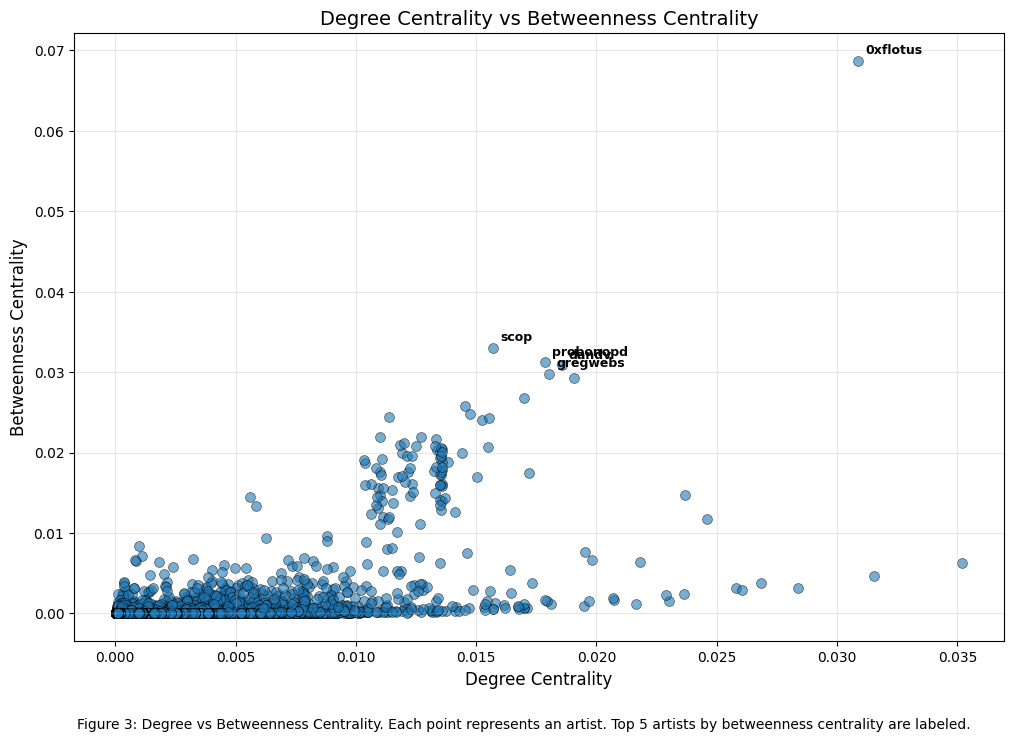


Correlation between degree and betweenness centrality: 0.4194


In [40]:
fig, ax = plt.subplots(figsize=(12, 8))

degree_values = list(degree_centrality.values())
betweenness_values = list(betweenness_centrality.values())
artists = list(degree_centrality.keys())

ax.scatter(degree_values, betweenness_values, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Degree Centrality', fontsize=12)
ax.set_ylabel('Betweenness Centrality', fontsize=12)
ax.set_title('Degree Centrality vs Betweenness Centrality', fontsize=14)
ax.grid(True, alpha=0.3)

top_5_betweenness_artists = [artist for artist, _ in top_betweenness[:5]]
for artist in top_5_betweenness_artists:
    idx = artists.index(artist)
    ax.annotate(artist, 
                (degree_values[idx], betweenness_values[idx]),
                fontsize=9,
                fontweight='bold',
                xytext=(5, 5),
                textcoords='offset points')

plt.figtext(0.5, 0.01, "Figure 3: Degree vs Betweenness Centrality. Each point represents an artist. " \
            "Top 5 artists by betweenness centrality are labeled.",
            ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.12)
plt.show()

corr_deg_bet = np.corrcoef(degree_values, betweenness_values)[0, 1]
print(f"\nCorrelation between degree and betweenness centrality: {corr_deg_bet:.4f}")

# Language statistics

In [9]:
import json

def calculate_language_statistics(repo_data):
    """
    Calculate total bytes per language across all repos.
    
    Returns:
        dict: {language: total_bytes}
    """
    language_totals = {}
    
    for repo, data in repo_data.items():
        languages = data.get("languages", {})
        for lang, bytes_count in languages.items():
            if lang not in language_totals:
                language_totals[lang] = 0
            language_totals[lang] += bytes_count
    
    # Calculate total bytes across all languages
    total_bytes = sum(language_totals.values())
    
    # Print results
    print(f"Total bytes of code: {total_bytes:,}")
    print(f"Number of different languages: {len(language_totals)}")
    print("\nTop 10 languages by bytes:")
    
    # Sort by bytes (descending)
    sorted_langs = sorted(language_totals.items(), key=lambda x: x[1], reverse=True)
    for i, (lang, bytes_count) in enumerate(sorted_langs[:10], 1):
        percentage = (bytes_count / total_bytes) * 100
        print(f"  {i}. {lang}: {bytes_count:,} bytes ({percentage:.2f}%)")
    
    return language_totals

with open("repo_data.json", "r") as f:
    repo_data = json.load(f)

# Now run the statistics
lang_stats = calculate_language_statistics(repo_data)

Total bytes of code: 24,863,672,257
Number of different languages: 275

Top 10 languages by bytes:
  1. Java: 8,957,011,912 bytes (36.02%)
  2. C: 6,786,722,884 bytes (27.30%)
  3. TypeScript: 2,154,463,952 bytes (8.67%)
  4. Python: 1,278,024,712 bytes (5.14%)
  5. C++: 1,013,067,418 bytes (4.07%)
  6. C#: 718,123,768 bytes (2.89%)
  7. JavaScript: 687,557,882 bytes (2.77%)
  8. Go: 529,776,827 bytes (2.13%)
  9. HTML: 368,433,489 bytes (1.48%)
  10. DM: 319,012,258 bytes (1.28%)


# Communities

In [20]:
def detect_structural_communities(G):
    communities = nx.community.louvain_communities(G, seed=42)
    partition = {}
    for comm_id, community in enumerate(communities):
        for node in community:
            partition[node] = comm_id
    modularity = nx.community.modularity(G, communities)
    return communities, partition, modularity

# Run on backbone
struct_communities, struct_partition, struct_modularity = detect_structural_communities(backbone)

print(f"Found {len(struct_communities)} communities")
print(f"Modularity: {struct_modularity:.4f}")
print(f"Total nodes: {len(struct_partition)}")

# Show top 10 communities by size
sizes = [(i, len(comm)) for i, comm in enumerate(struct_communities)]
sizes.sort(key=lambda x: x[1], reverse=True)

print("\nTop 10 communities:")
for rank, (comm_id, size) in enumerate(sizes[:10], 1):
    pct = (size / len(struct_partition)) * 100
    print(f"  {rank}. Community {comm_id}: {size} nodes ({pct:.1f}%)")

Found 113 communities
Modularity: 0.8108
Total nodes: 21889

Top 10 communities:
  1. Community 45: 2484 nodes (11.3%)
  2. Community 50: 2068 nodes (9.4%)
  3. Community 79: 1691 nodes (7.7%)
  4. Community 55: 1655 nodes (7.6%)
  5. Community 54: 1590 nodes (7.3%)
  6. Community 76: 1268 nodes (5.8%)
  7. Community 56: 1234 nodes (5.6%)
  8. Community 81: 868 nodes (4.0%)
  9. Community 24: 865 nodes (4.0%)
  10. Community 25: 803 nodes (3.7%)


# Languages per community

In [21]:
def analyze_community_languages(communities, partition, repo_data):
    """
    Find dominant languages for each community.
    """
    community_languages = {}
    
    for comm_id in range(len(communities)):
        # Get all users in this community
        users = [node for node, c in partition.items() if c == comm_id]
        
        # Count language bytes for this community
        lang_bytes = {}
        for user in users:
            # Get repos for this user from backbone graph
            repos_str = backbone.nodes[user].get("repos", "")
            if repos_str:
                repos = [r.strip() for r in repos_str.split(",")]
                for repo in repos:
                    if repo in repo_data:
                        languages = repo_data[repo].get("languages", {})
                        for lang, bytes_count in languages.items():
                            if lang not in lang_bytes:
                                lang_bytes[lang] = 0
                            lang_bytes[lang] += bytes_count
        
        community_languages[comm_id] = lang_bytes
    
    return community_languages

# Analyze languages per community
comm_langs = analyze_community_languages(struct_communities, struct_partition, repo_data)

# Show top 3 languages for top 10 communities
print("Top languages per community:\n")
for rank, (comm_id, size) in enumerate(sizes[:10], 1):
    langs = comm_langs[comm_id]
    total = sum(langs.values())
    top_langs = sorted(langs.items(), key=lambda x: x[1], reverse=True)[:3]
    
    print(f"{rank}. Community {comm_id} ({size} nodes):")
    for lang, bytes_count in top_langs:
        pct = (bytes_count / total * 100) if total > 0 else 0
        print(f"   - {lang}: {pct:.1f}%")
    print()

Top languages per community:

1. Community 45 (2484 nodes):
   - C: 30.9%
   - TypeScript: 26.4%
   - C++: 10.1%

2. Community 50 (2068 nodes):
   - Java: 84.2%
   - Python: 4.7%
   - C++: 2.7%

3. Community 79 (1691 nodes):
   - Java: 67.0%
   - TypeScript: 11.8%
   - C++: 9.4%

4. Community 55 (1655 nodes):
   - C#: 30.1%
   - Ruby: 24.3%
   - C++: 17.5%

5. Community 54 (1590 nodes):
   - C: 65.2%
   - Go: 13.6%
   - JavaScript: 7.0%

6. Community 76 (1268 nodes):
   - Go: 64.8%
   - Java: 9.8%
   - C: 8.0%

7. Community 56 (1234 nodes):
   - C: 35.3%
   - C++: 25.7%
   - Python: 10.9%

8. Community 81 (868 nodes):
   - C: 67.1%
   - Java: 5.4%
   - Assembly: 5.0%

9. Community 24 (865 nodes):
   - PHP: 25.3%
   - C#: 22.4%
   - Java: 14.5%

10. Community 25 (803 nodes):
   - Java: 38.4%
   - Groovy: 19.6%
   - C++: 13.3%



In [22]:
def create_language_communities(partition, repo_data, min_bytes_threshold=10000):
    """
    Assign users to communities based on their primary language.
    
    Returns:
        dict: {node: primary_language}
    """
    user_primary_lang = {}
    
    for user in partition.keys():
        # Get repos for this user
        repos_str = backbone.nodes[user].get("repos", "")
        if not repos_str:
            continue
        
        repos = [r.strip() for r in repos_str.split(",")]
        
        # Count language bytes for this user
        lang_bytes = {}
        for repo in repos:
            if repo in repo_data:
                languages = repo_data[repo].get("languages", {})
                for lang, bytes_count in languages.items():
                    if lang not in lang_bytes:
                        lang_bytes[lang] = 0
                    lang_bytes[lang] += bytes_count
        
        # Assign primary language (most bytes)
        if lang_bytes:
            primary = max(lang_bytes, key=lang_bytes.get)
            if lang_bytes[primary] >= min_bytes_threshold:
                user_primary_lang[user] = primary
    
    print(f"Assigned primary language to {len(user_primary_lang)} users")
    print(f"Found {len(set(user_primary_lang.values()))} different languages")
    
    return user_primary_lang

# Create language-based communities
lang_partition = create_language_communities(struct_partition, repo_data)

Assigned primary language to 21015 users
Found 51 different languages


In [23]:
def compare_communities(structural_partition, language_partition):
    """
    Compare structural (Louvain) communities with language-based communities.
    
    For each structural community, find which language dominates it.
    """
    # Get users that have both assignments
    common_users = set(structural_partition.keys()) & set(language_partition.keys())
    
    print(f"Comparing {len(common_users)} users with both community assignments\n")
    
    # For each structural community, count languages
    struct_comm_langs = {}
    for user in common_users:
        struct_comm = structural_partition[user]
        lang = language_partition[user]
        
        if struct_comm not in struct_comm_langs:
            struct_comm_langs[struct_comm] = {}
        
        if lang not in struct_comm_langs[struct_comm]:
            struct_comm_langs[struct_comm][lang] = 0
        
        struct_comm_langs[struct_comm][lang] += 1
    
    # Show results for top 10 structural communities
    print(f"{'Structural Community':<25} {'Size':<10} {'Dominant Language':<20} {'Purity'}")
    print("-" * 80)
    
    for rank, (comm_id, size) in enumerate(sizes[:10], 1):
        if comm_id in struct_comm_langs:
            langs = struct_comm_langs[comm_id]
            total = sum(langs.values())
            top_lang = max(langs, key=langs.get)
            purity = (langs[top_lang] / total * 100) if total > 0 else 0
            
            print(f"Community {comm_id:<15} {total:<10} {top_lang:<20} {purity:.1f}%")
    
    # Overall purity metric
    matches = 0
    for comm_id, langs in struct_comm_langs.items():
        total = sum(langs.values())
        top_lang_count = max(langs.values())
        matches += top_lang_count
    
    overall_purity = (matches / len(common_users) * 100) if common_users else 0
    print(f"\nOverall language purity: {overall_purity:.1f}%")
    print("(What % of users are in their language's dominant structural community)")
    
    return struct_comm_langs

# Run comparison
struct_comm_langs = compare_communities(struct_partition, lang_partition)

Comparing 21015 users with both community assignments

Structural Community      Size       Dominant Language    Purity
--------------------------------------------------------------------------------
Community 45              2387       Python               22.0%
Community 50              1931       Python               23.3%
Community 79              1691       Java                 31.0%
Community 55              1544       Ruby                 27.1%
Community 54              1433       Go                   34.8%
Community 76              1265       Go                   52.1%
Community 56              1193       C++                  21.9%
Community 81              868        C                    34.1%
Community 24              865        Python               19.2%
Community 25              741        Java                 36.8%

Overall language purity: 41.7%
(What % of users are in their language's dominant structural community)


# Semantics analysis

In [10]:
def extract_readme_texts(repo_data):
    """
    Extract all README texts from repo_data.
    
    Returns:
        list of strings (one per repo with a README)
    """
    readme_texts = []
    
    for repo, data in repo_data.items():
        readme = data.get("readme")
        if readme:
            readme_texts.append(readme)
    
    print(f"Found {len(readme_texts)} repos with READMEs")
    return readme_texts

readmes = extract_readme_texts(repo_data)

Found 3537 repos with READMEs


# Wordclouds

In [15]:
from wordcloud import STOPWORDS
import re

def clean_readme_text(text):
    """
    Clean a single README text.
    """
    if not text:
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove markdown links [text](url)
    text = re.sub(r'\[([^\]]+)\]\([^\)]+\)', r'\1', text)
    
    # Remove code blocks (```)
    text = re.sub(r'```[\s\S]*?```', '', text)
    
    # Remove inline code (`)
    text = re.sub(r'`[^`]*`', '', text)
    
    # Remove special characters but keep spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def clean_readmes(readme_texts):
    """
    Clean all README texts.
    """
    cleaned = [clean_readme_text(text) for text in readme_texts]
    print(f"Cleaned {len(cleaned)} READMEs")
    return cleaned

# Clean the readmes
cleaned_readmes = clean_readmes(readmes)

Cleaned 3537 READMEs


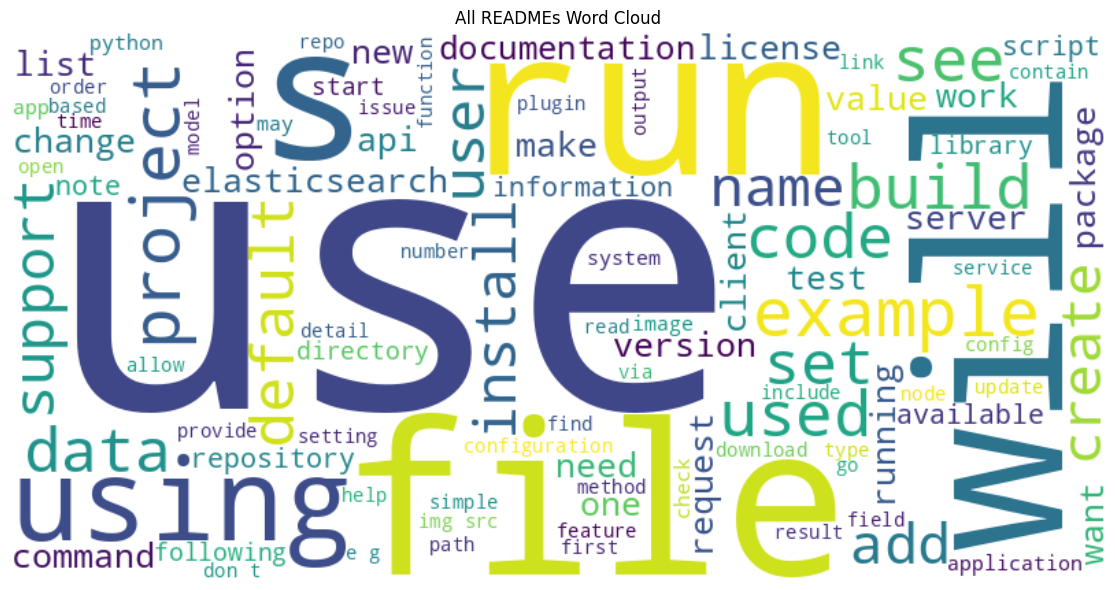

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_wordcloud(texts, title="Word Cloud"):
    """
    Create a word cloud from a list of texts.
    
    Parameters:
        texts: list of strings
        title: title for the plot
    """
    # Combine all texts
    combined_text = " ".join(texts)
    
    # Create word cloud
    wordcloud = WordCloud(
        width=800, 
        height=400,
        background_color='white',
        max_words=100
    ).generate(combined_text)
    
    # Display
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Create overall word cloud
create_wordcloud(cleaned_readmes, "All READMEs Word Cloud")

# TF-IDF

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

def get_community_readmes(community_id, partition, repo_data):
    """
    Collect all README texts for users in a specific community.
    """
    # Get users in this community
    users = [node for node, comm in partition.items() if comm == community_id]
    
    # Collect their READMEs
    readmes = []
    for user in users:
        repos_str = backbone.nodes[user].get("repos", "")
        if repos_str:
            repos = [r.strip() for r in repos_str.split(",")]
            for repo in repos:
                if repo in repo_data:
                    readme = repo_data[repo].get("readme")
                    if readme:
                        readmes.append(readme)
    
    return readmes

def analyze_community_tfidf(community_id, partition, repo_data, top_n=10):
    """
    Find top TF-IDF terms for a specific community.
    """
    # Get READMEs for this community
    readmes = get_community_readmes(community_id, partition, repo_data)
    
    if not readmes:
        return []
    
    # Clean the READMEs
    cleaned = [clean_readme_text(text) for text in readmes]
    
    # Combine into one document for this community
    community_text = " ".join(cleaned)
    
    return community_text, len(readmes)

# Collect texts for top 5 communities
print("Collecting README texts for top communities...\n")

community_texts = {}
for rank, (comm_id, size) in enumerate(sizes[:5], 1):
    text, readme_count = analyze_community_tfidf(comm_id, struct_partition, repo_data)
    community_texts[comm_id] = text
    print(f"Community {comm_id}: {readme_count} READMEs")


Community 45: 3424 READMEs
Community 50: 2453 READMEs
Community 79: 2355 READMEs
Community 55: 2559 READMEs
Community 54: 2529 READMEs


In [26]:
def compare_communities_tfidf(community_texts, top_n=15):
    """
    Use TF-IDF to find distinctive words for each community.
    """
    # Prepare documents (one per community)
    comm_ids = list(community_texts.keys())
    documents = [community_texts[cid] for cid in comm_ids]
    
    # Custom stopwords
    custom_stopwords = list(STOPWORDS)
    custom_stopwords.extend([
        'use', 'used', 'using', 'run', 'file', 'will', 'one', 'two',
        'project', 'new', 'set', 'may', 'also', 'see', 'get', 'make',
        'example', 'install', 'start', 'first', 'need', 'add', 'name',
        'following', 'via', 'note', 'number', 'type', 'value', 'result',
        'allow', 'include', 'provide', 'contain', 'based', 'support'
    ])
    
    # Compute TF-IDF
    vectorizer = TfidfVectorizer(
        max_features=1000,
        stop_words=custom_stopwords,
        min_df=1,
        ngram_range=(1, 2)  # Include bigrams
    )
    
    tfidf_matrix = vectorizer.fit_transform(documents)
    feature_names = vectorizer.get_feature_names_out()
    
    # Get top terms for each community
    print(f"{'Community':<15} {'Top Distinctive Terms'}")
    print("=" * 80)
    
    for idx, comm_id in enumerate(comm_ids):
        # Get TF-IDF scores for this community
        scores = tfidf_matrix[idx].toarray()[0]
        top_indices = scores.argsort()[-top_n:][::-1]
        top_terms = [feature_names[i] for i in top_indices]
        
        # Get dominant language for context
        if comm_id in struct_comm_langs:
            langs = struct_comm_langs[comm_id]
            top_lang = max(langs, key=langs.get)
        else:
            top_lang = "Unknown"
        
        print(f"\nCommunity {comm_id:<5} ({top_lang}):")
        print(f"  {', '.join(top_terms)}")

# Run TF-IDF comparison
compare_communities_tfidf(community_texts, top_n=15)

/home/marcus/projects/dtu/SG_rock_network/graph_viz_env/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


Community       Top Distinctive Terms

Community 45    (Python):
  examples, examples tools, tools, src, kbd, client, asciidoctor, react, trace, uri, href, jsx, target, clj, img

Community 50    (Python):
  terraform, aws, sdk, code, api, docs, license, service, sdl, credentials, build, information, mail, documentation, request

Community 79    (Java):
  angular, code, href, tools, examples, alt, src, version, br, md, examples tools, align, center, contributing, align center

Community 55    (Ruby):
  codechecker, license, code, homebrew, documentation, analysis, cask, build, server, github, net, src, jitsi, source, href

Community 54    (Go):
  kubernetes, alloy, src, build, charts, image, license, href, pyodide, status, code, registry, community, configuration, cluster


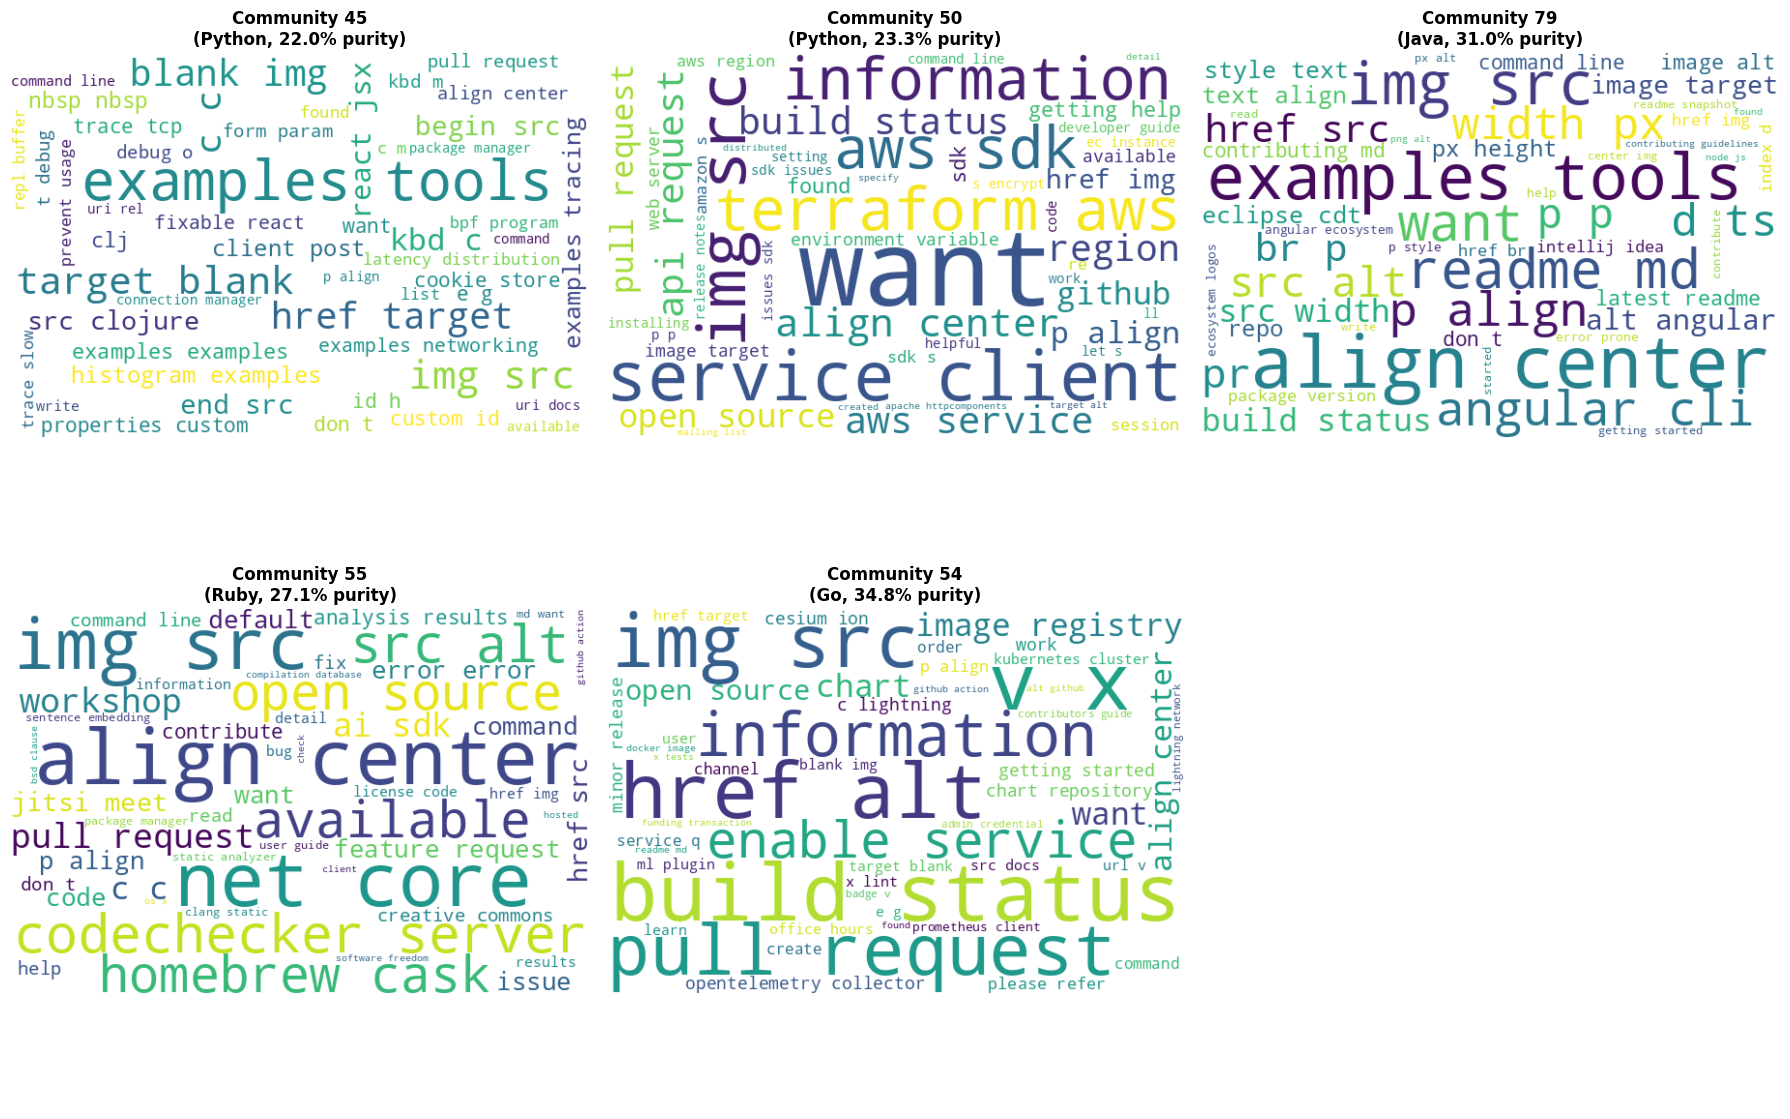

In [27]:
def create_community_wordclouds(community_texts, struct_comm_langs):
    """
    Create word clouds for each community.
    """
    # Custom stopwords
    custom_stopwords = STOPWORDS.copy()
    custom_stopwords.update([
        'use', 'used', 'using', 'run', 'file', 'will', 'one', 'two',
        'project', 'new', 'set', 'may', 'also', 'see', 'get', 'make',
        'example', 'install', 'start', 'first', 'need', 'add', 'name',
        'following', 'via', 'note', 'number', 'type', 'value', 'result',
        'allow', 'include', 'provide', 'contain', 'based', 'support'
    ])
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, (comm_id, text) in enumerate(community_texts.items()):
        # Get dominant language
        if comm_id in struct_comm_langs:
            langs = struct_comm_langs[comm_id]
            top_lang = max(langs, key=langs.get)
            purity = (langs[top_lang] / sum(langs.values()) * 100)
        else:
            top_lang = "Unknown"
            purity = 0
        
        # Create wordcloud
        wordcloud = WordCloud(
            width=600,
            height=400,
            background_color='white',
            max_words=50,
            stopwords=custom_stopwords,
            colormap='viridis'
        ).generate(text)
        
        # Plot
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].axis('off')
        axes[idx].set_title(f'Community {comm_id}\n({top_lang}, {purity:.1f}% purity)', 
                           fontsize=12, fontweight='bold')
    
    # Hide extra subplot if we have fewer than 6 communities
    if len(community_texts) < 6:
        for idx in range(len(community_texts), 6):
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Create wordclouds
create_community_wordclouds(community_texts, struct_comm_langs)

# 6 degrees of separation experiments

In [49]:
import random

def test_small_world(G, num_samples=10000):
    """
    Test small-world phenomenon by finding shortest paths between random node pairs.
    
    Parameters:
        G: NetworkX graph
        num_samples: Number of random pairs to test
    
    Returns:
        list of path lengths
    """
    nodes = list(G.nodes())
    path_lengths = []
    no_path_count = 0
    
    print(f"Testing {num_samples} random node pairs...\n")
    
    for i in range(num_samples):
        # Pick two random nodes
        node1, node2 = random.sample(nodes, 2)
        
        try:
            # Use your existing function
            path = shortest_path_between_users(G, node1, node2)
            path_length = len(path) - 1  # Number of edges
            path_lengths.append(path_length)
            
            if i < 10:  # Show first 10 examples
                print(f"{i+1}. {node1} → {node2}: {path_length} steps")
        
        except (nx.NetworkXNoPath, ValueError):
            no_path_count += 1
            if i < 10:
                print(f"{i+1}. {node1} → {node2}: No path (disconnected)")
    
    # Statistics
    if path_lengths:
        print(f"\n{'='*60}")
        print(f"Results from {len(path_lengths)} connected pairs:")
        print(f"  Average path length: {np.mean(path_lengths):.2f}")
        print(f"  Median path length: {np.median(path_lengths):.1f}")
        print(f"  Min path length: {min(path_lengths)}")
        print(f"  Max path length: {max(path_lengths)}")
        print(f"  Disconnected pairs: {no_path_count}/{num_samples}")
    
    return path_lengths

# Run experiment
path_lengths = test_small_world(backbone, num_samples=1000)

Testing 1000 random node pairs...

1. christiangalsterer → bensternthal: 4 steps
2. iartarisi → ronyv89: 5 steps
3. joemaller → mabis: 5 steps
4. GenevieveBuckley → PaulSandoz: 4 steps
5. MechCoder → deining: 4 steps
6. jantlwoomy → GerHobbelt: 4 steps
7. breskeby → jschneider: 4 steps
8. leodutra → ywkim: 6 steps
9. Damianofds → nishantsikarwar: 5 steps
10. galleon → abuckenheimer: 5 steps

Results from 1000 connected pairs:
  Average path length: 4.25
  Median path length: 4.0
  Min path length: 1
  Max path length: 8
  Disconnected pairs: 0/1000
